In [2]:
#!/bin/bash
!curl -L -o bank-marketing.zip\
  https://www.kaggle.com/api/v1/datasets/download/henriqueyamahata/bank-marketing

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  393k  100  393k    0     0   466k      0 --:--:-- --:--:-- --:--:-- 22.8M


In [3]:
!unzip /content/bank-marketing.zip

Archive:  /content/bank-marketing.zip
  inflating: bank-additional-full.csv  
  inflating: bank-additional-names.txt  


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import  Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score,recall_score,precision_score,roc_auc_score,classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay,RocCurveDisplay

In [5]:
df = pd.read_csv('/content/bank-additional-full.csv',sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [45]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
housing,0
loan,0
contact,0
month,0
campaign,0
previous,0


In [7]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
df.nunique()

,0
age,78
job,12
marital,4
education,8
default,3
housing,3
loan,3
contact,2
month,10
day_of_week,5


In [9]:
cat_cols = [col for col in  df.columns if df[col].dtypes in ['bool','category','object']]
cat_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

In [10]:
num_cols = [col for col in df.columns if df[col].dtypes in ['float64','int64']]
num_cols

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

<Axes: >

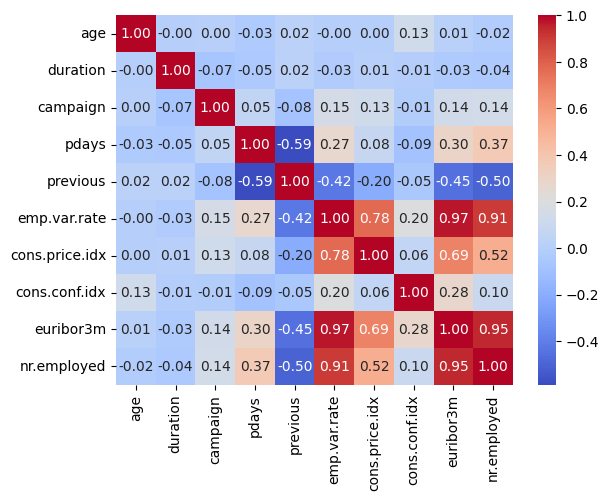

In [11]:
sns.heatmap(df.corr(numeric_only = True),annot = True,fmt = '.2f',cmap = 'coolwarm')

In [12]:
df.drop(columns=['emp.var.rate', 'nr.employed'], inplace=True)

`emp.var.rate` və `nr.employed` sütunları `euribor3m` ilə müvafiq olaraq 0.97 və 0.95 korrelyasiyaya malik idi.
Multikollinearlik riskini azaltmaq üçün silindi.

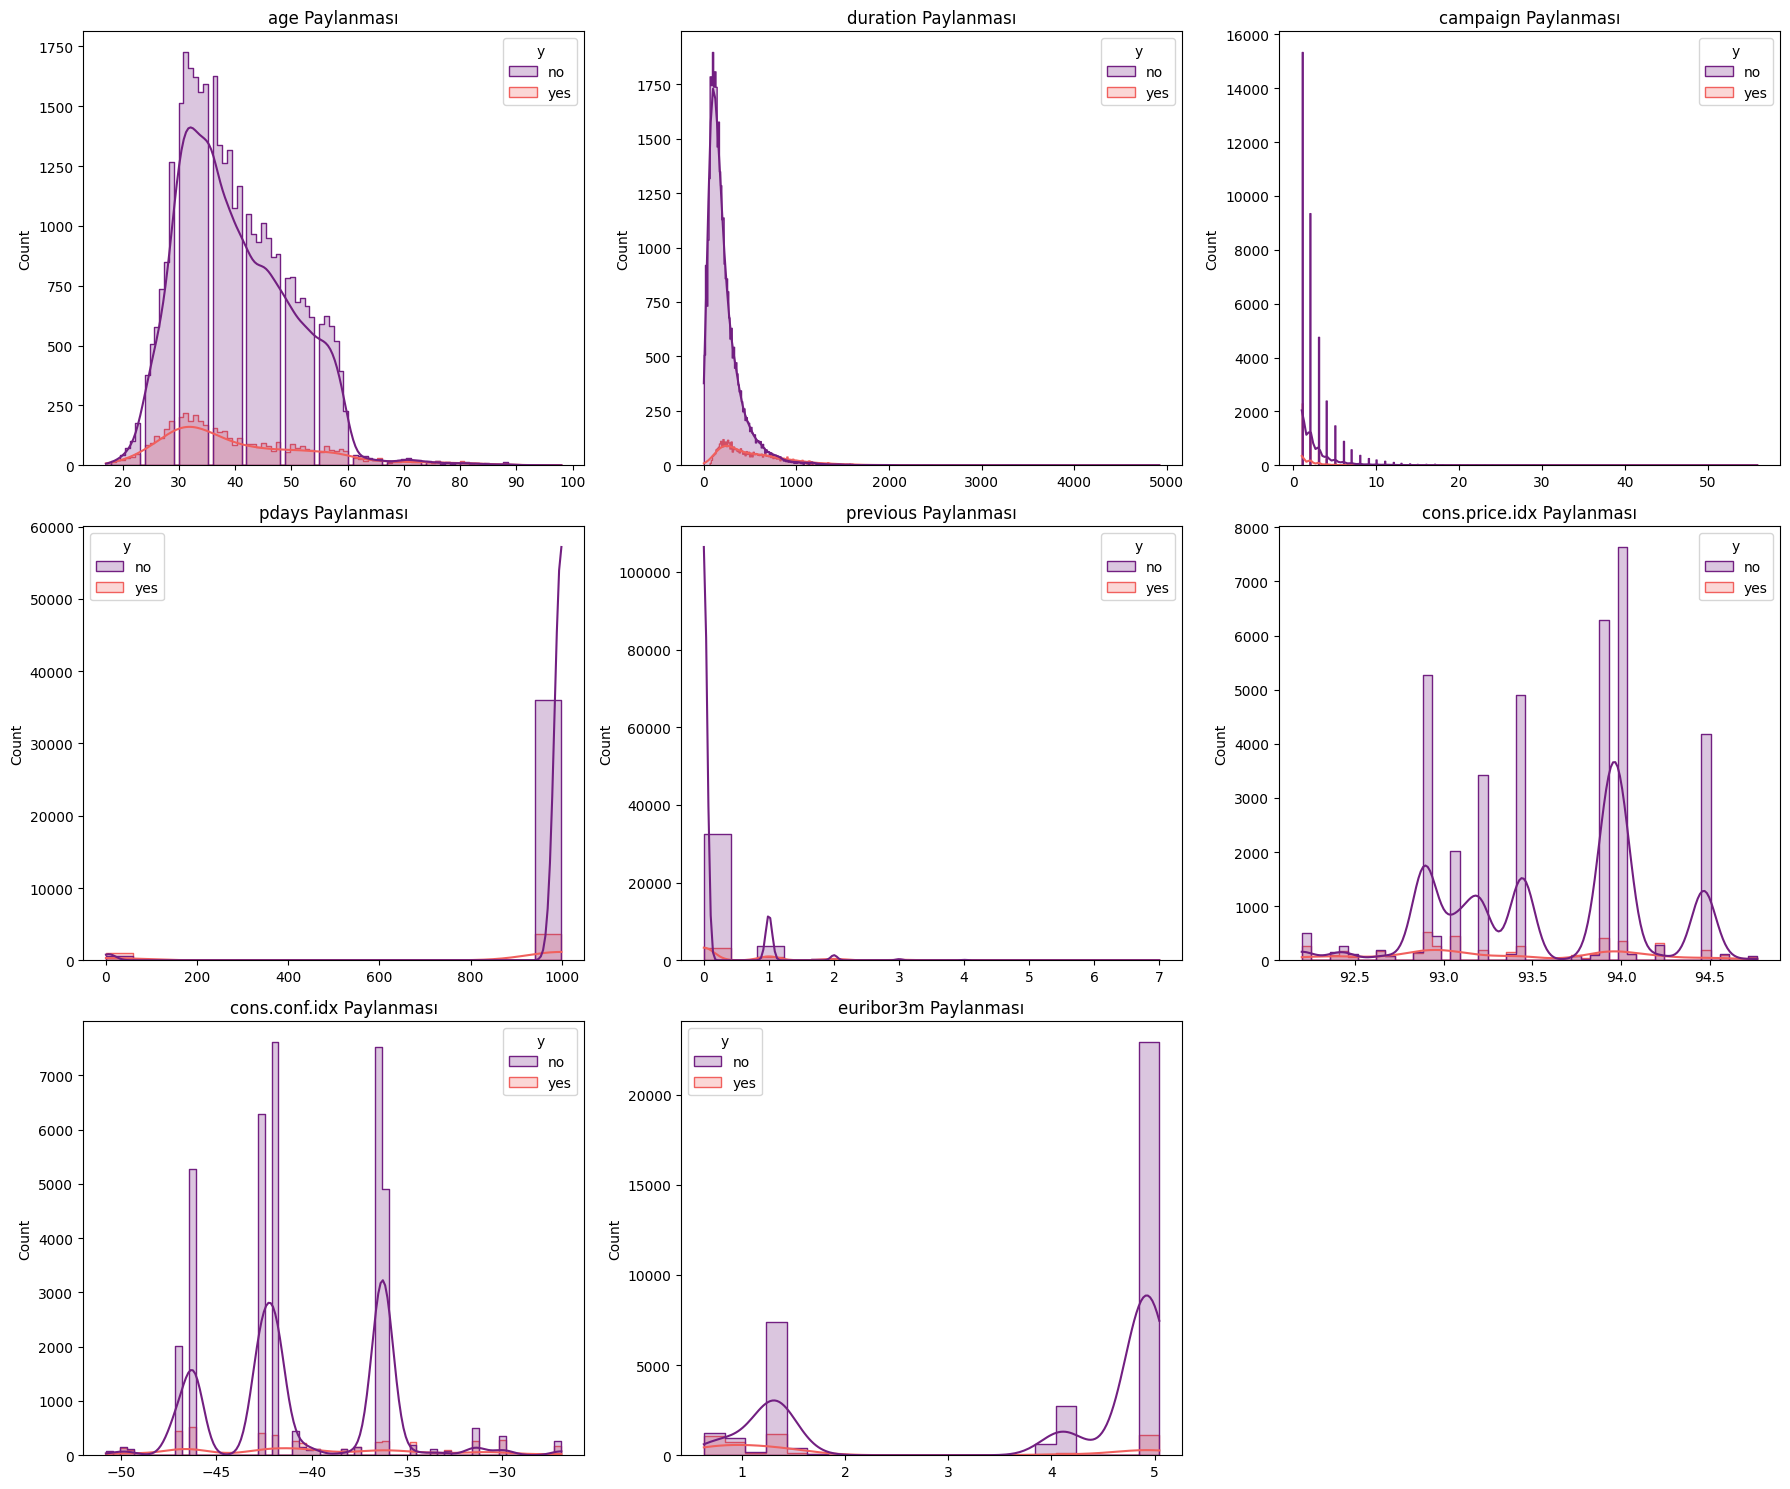

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(18, 15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=df, x=col, hue='y', kde=True, palette='magma', element="step")
    plt.title(f'{col} Paylanması')
    plt.xlabel('')

plt.tight_layout()
plt.show()

In [14]:
df.drop('pdays', axis=1, inplace=True)

Hər numeric dəyişənin hədəf dəyişəni (`y`) ilə paylanması histplot vasitəsilə analiz edildi.
`pdays` sütununun ~96%-i 999 dəyərindən ibarət olduğu aşkar edildi — real məlumat daşımadığı üçün silindi.



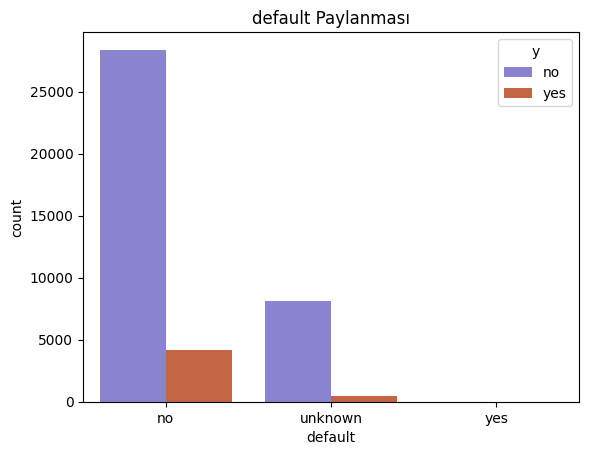

In [15]:
sns.countplot(data=df, x='default', hue='y', palette={'no':'#7F77DD', 'yes':'#D85A30'})
plt.title('default Paylanması')
plt.show()

`default` sütununun `y` hədəfinə görə paylanması countplot ilə vizuallaşdırıldı.
`yes` kateqoriyası demək olar ki, sıfır idi — model üçün heç bir məlumat daşımadığı üçün silindi.


In [16]:
df.drop('default', axis=1, inplace=True)

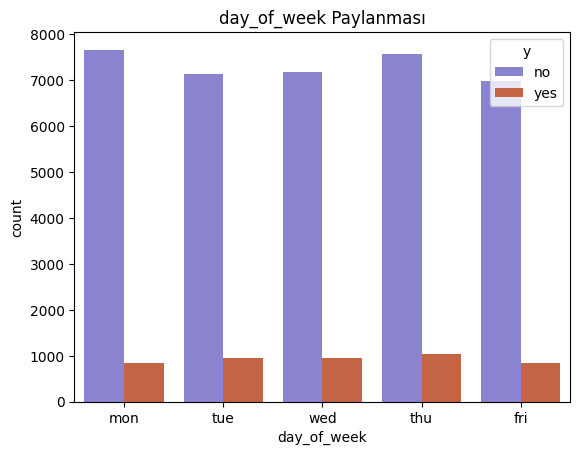

In [17]:
sns.countplot(data=df, x='day_of_week', hue='y', palette={'no':'#7F77DD', 'yes':'#D85A30'})
plt.title('day_of_week Paylanması')
plt.show()

In [18]:
df.drop('day_of_week', axis=1, inplace=True)


`day_of_week` sütununun `y` hədəfinə görə paylanması countplot ilə vizuallaşdırıldı.
Bütün günlər üçün `yes`/`no` nisbəti demək olar ki, eyni idi — hədəflə əlaqəsi olmadığı üçün silindi.

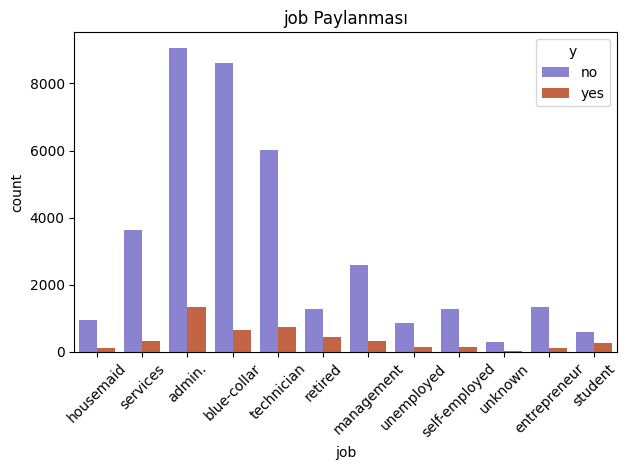

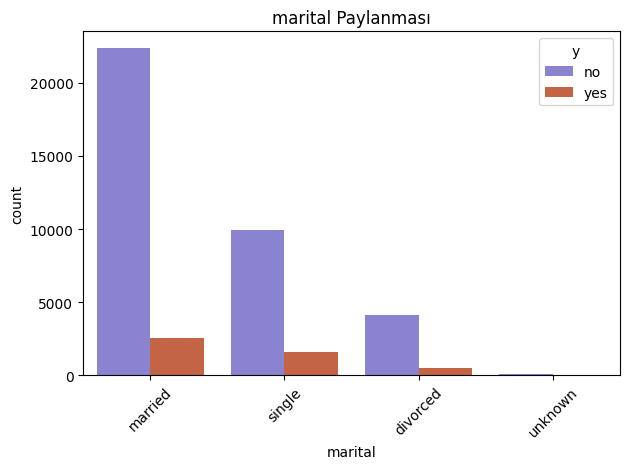

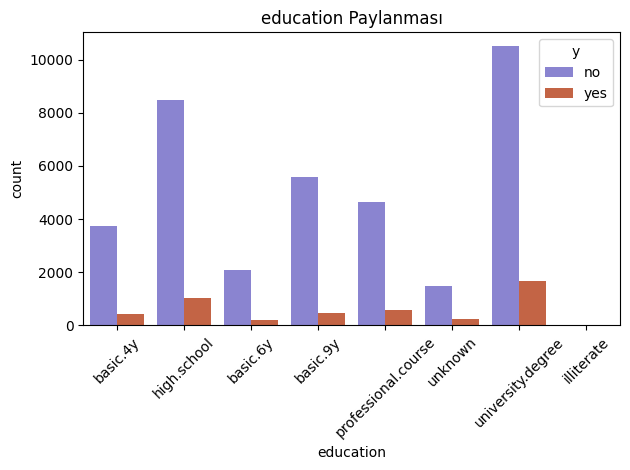

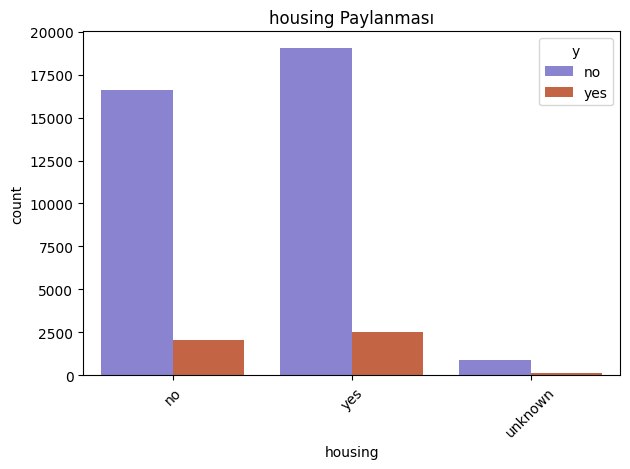

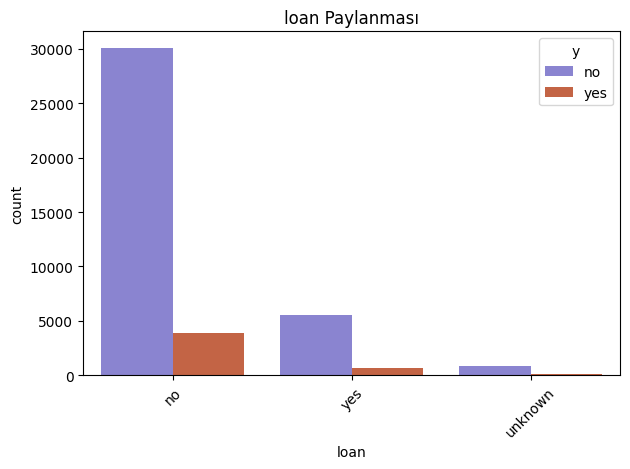

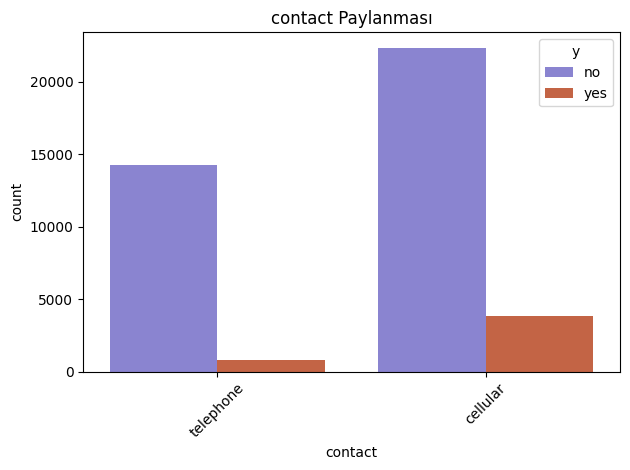

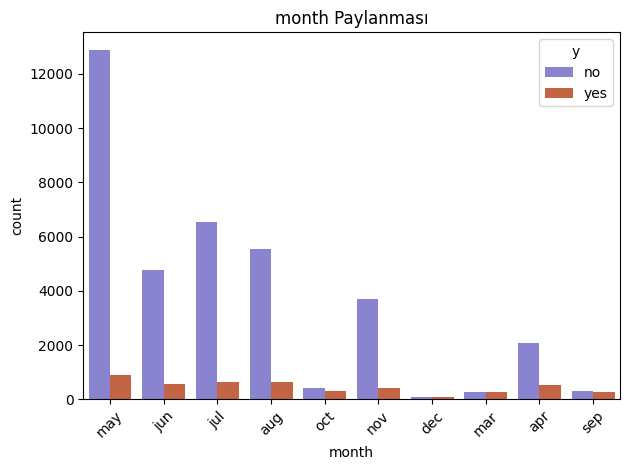

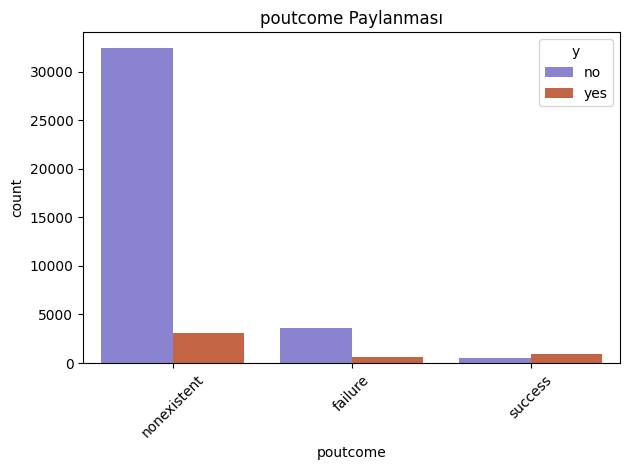

In [19]:
cat_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'poutcome']

for col in cat_cols:
    sns.countplot(data=df, x=col, hue='y', palette={'no':'#7F77DD', 'yes':'#D85A30'})
    plt.title(f'{col} Paylanması')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

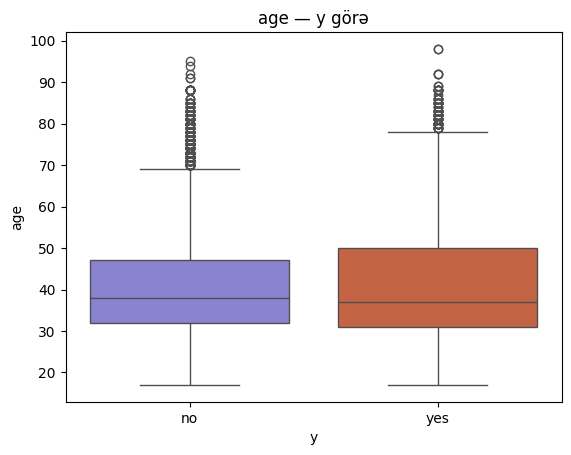

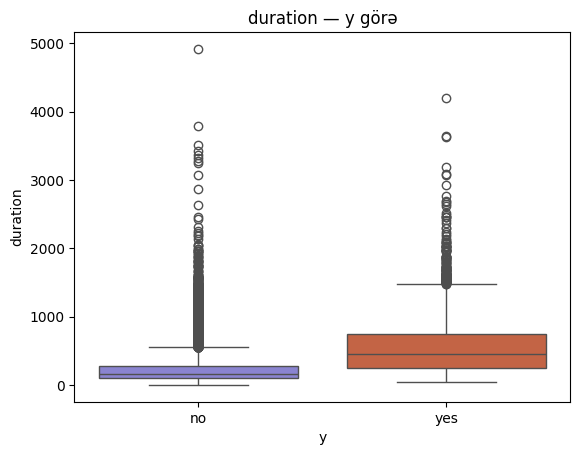

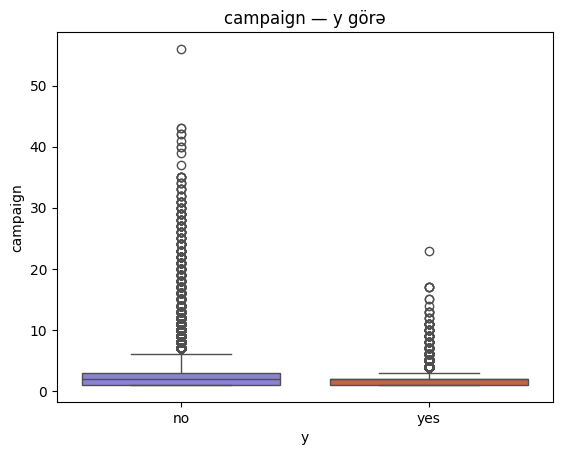

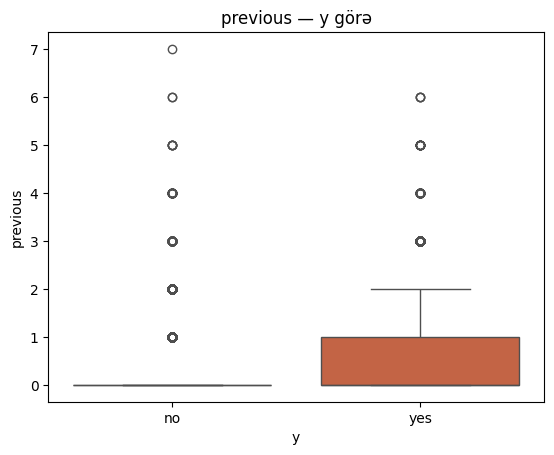

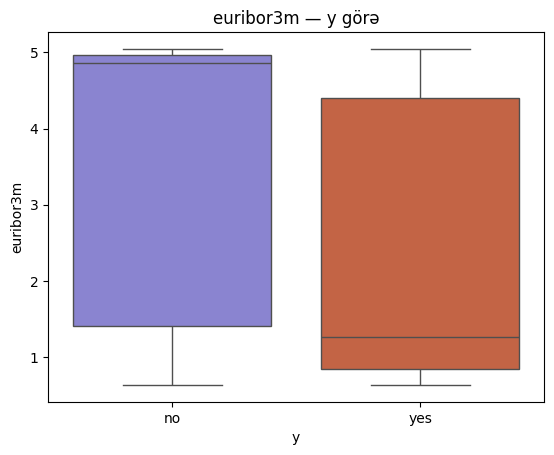

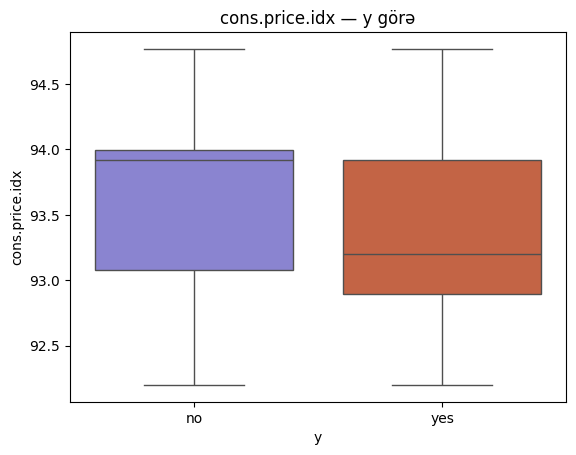

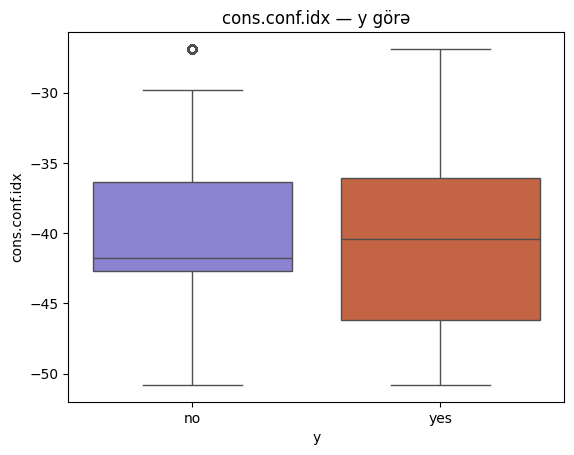

In [20]:
num_cols = ['age', 'duration', 'campaign', 'previous', 'euribor3m', 'cons.price.idx', 'cons.conf.idx']

for col in num_cols:
    sns.boxplot(data=df, x='y', y=col, palette={'no':'#7F77DD', 'yes':'#D85A30'})
    plt.title(f'{col} — y görə')
    plt.show()

In [21]:
df.drop('duration', axis=1, inplace=True)

Numeric dəyişənlərin `y` hədəfinə görə boxplot analizi aparıldı.
`duration` sütunu `yes` qrupunda əhəmiyyətli dərəcədə yüksək idi, lakin zəngin nəticəsi məlum olduqdan sonra ölçüldüyü üçün data leakage riski var — silindi.
Qalan dəyişənlər saxlandı.

In [22]:
num_cols = ['age', 'campaign', 'previous', 'euribor3m', 'cons.price.idx', 'cons.conf.idx']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

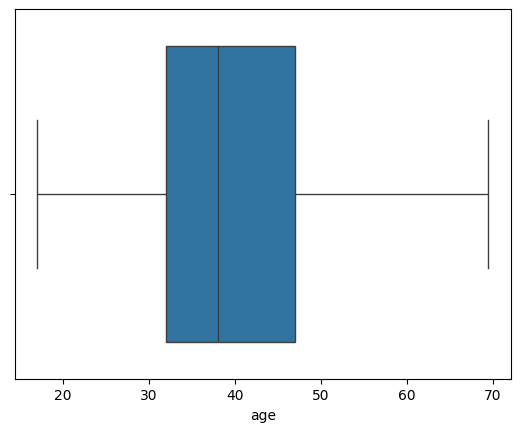

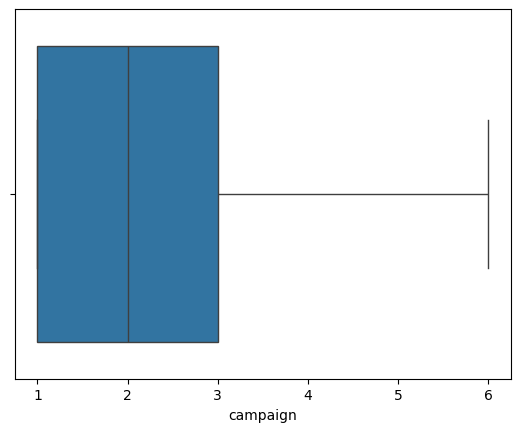

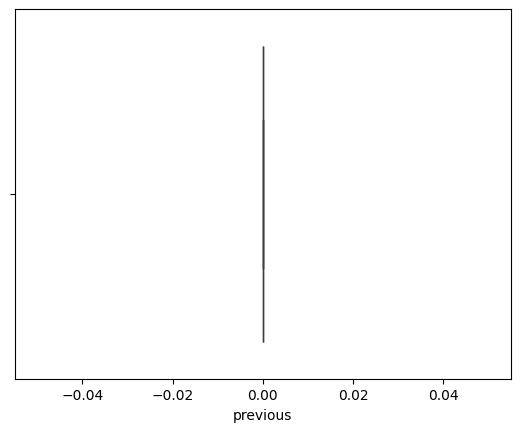

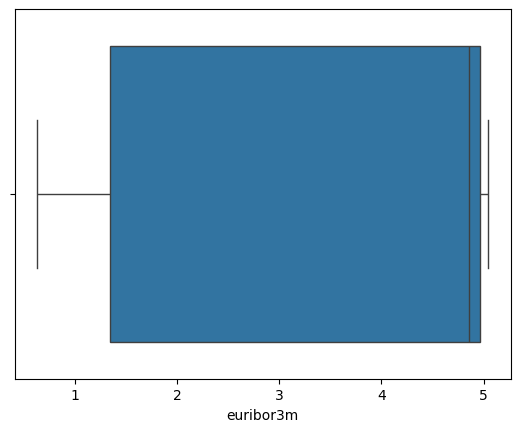

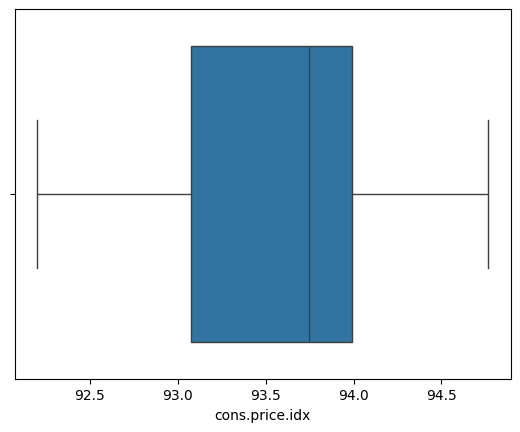

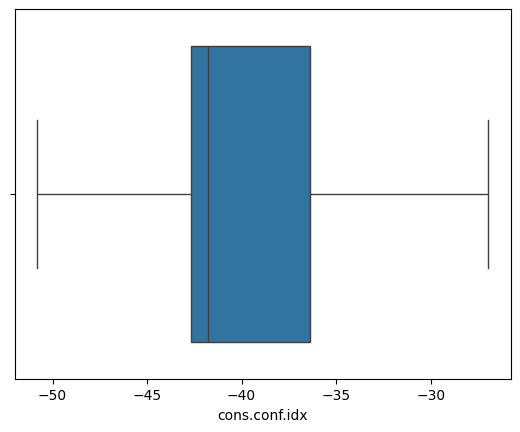

In [23]:
num_cols = ['age', 'campaign', 'previous', 'euribor3m', 'cons.price.idx', 'cons.conf.idx']

for col in num_cols:
    sns.boxplot(data=df, x= col)

    plt.show()

In [24]:
X = df.drop(columns=['y'])
Y = df['y']
le = LabelEncoder()
Y = le.fit_transform(Y)

In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


Dataset 80% train, 20% test olaraq bölündü.

In [26]:
num_features = X_train.select_dtypes(include = [np.number]).columns
cat_features = X_train.select_dtypes(exclude =  [np.number]).columns
print("Numeric:",num_features)
print("Cat_cols:" ,cat_features)

Numeric: Index(['age', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m'],
      dtype='object')
Cat_cols: Index(['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month',
       'poutcome'],
      dtype='object')



Numeric dəyişənlər üçün median imputer + StandardScaler, kateqorik dəyişənlər üçün most_frequent imputer + OneHotEncoder tətbiq edildi.

In [27]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
], remainder='passthrough')

Logistic Regression

In [28]:

model = Pipeline([
    ('preprocessor', preprocessing),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

model.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  Index(['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month',
       'poutcome'],
      dtype='object'))])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

In [29]:
Y_pred = model.predict(X_test)

In [32]:
print(classification_report(Y_test, Y_pred))
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("F1 Score:", f1_score(Y_test, Y_pred, pos_label=1))
print("ROC AUC:", roc_auc_score(Y_test, model.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89      7303
           1       0.34      0.61      0.44       935

    accuracy                           0.82      8238
   macro avg       0.64      0.73      0.66      8238
weighted avg       0.88      0.82      0.84      8238

Accuracy: 0.8203447438698713
F1 Score: 0.4368340943683409
ROC AUC: 0.7791384538329791
Confusion Matrix:
 [[6184 1119]
 [ 361  574]]


Random Forest

In [33]:


model_rf = Pipeline([
    ('preprocessor', preprocessing),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42,n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        ))
])

model_rf.fit(X_train, Y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  Index(['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month',
       'poutcome'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=5, n_estimators=200,
                                        random_state=42))])

In [34]:
y_pred_rf = model_rf.predict(X_test)


In [36]:
print(classification_report(Y_test, y_pred_rf))
print("F1 Score:", f1_score(Y_test, y_pred_rf, pos_label= 1))
print("ROC AUC:", roc_auc_score(Y_test, model_rf.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      7303
           1       0.39      0.59      0.47       935

    accuracy                           0.85      8238
   macro avg       0.67      0.73      0.69      8238
weighted avg       0.88      0.85      0.86      8238

F1 Score: 0.46649703138252757
ROC AUC: 0.7874858401902083


XGBoost

In [37]:


model_xgb = Pipeline([
    ('preprocessor', preprocessing),
    ('classifier', XGBClassifier(scale_pos_weight=7,
        n_estimators=500,
        max_depth=8,
        learning_rate=0.01,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.5,
        random_state=42,
        eval_metric='logloss'))
])

model_xgb.fit(X_train,Y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_fre...
                               feature_types=None, feature_weights=None,
                               gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=8, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=500,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [38]:
y_pred_xgb = model_xgb.predict(X_test)

print(classification_report(  Y_test, y_pred_xgb))
print("F1 Score:", f1_score(Y_test, y_pred_xgb, pos_label=1))
print("ROC AUC:", roc_auc_score(Y_test, model_xgb.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      7303
           1       0.41      0.58      0.48       935

    accuracy                           0.86      8238
   macro avg       0.68      0.74      0.70      8238
weighted avg       0.88      0.86      0.87      8238

F1 Score: 0.48168007149240394
ROC AUC: 0.7851161452219841


Model Müqayisəsi
3 modelin F1 Score və ROC AUC nəticələrinin müqayisəsi.

In [54]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'F1 Score': [0.44, 0.47, 0.48],
    'ROC AUC': [0.78, 0.79, 0.79]
})
results

,Model,F1 Score,ROC AUC
0,Logistic Regression,0.44,0.78
1,Random Forest,0.47,0.79
2,XGBoost,0.48,0.79


Confusion Matrix
Modelin `yes` və `no` proqnozlarının real dəyərlərlə müqayisəsi.

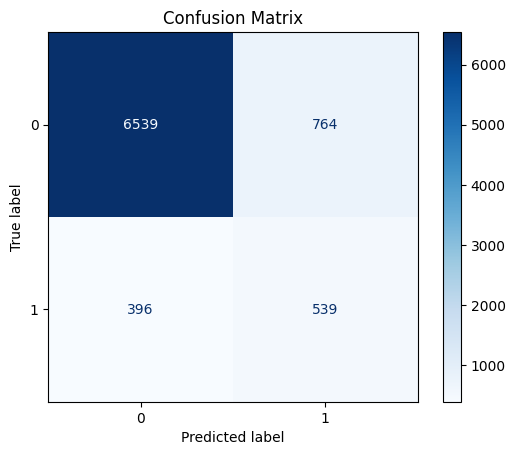

In [48]:
ConfusionMatrixDisplay.from_estimator(model_xgb, X_test, Y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

ROC Curve
Modelin ayırd etmə gücü — AUC: 0.79.

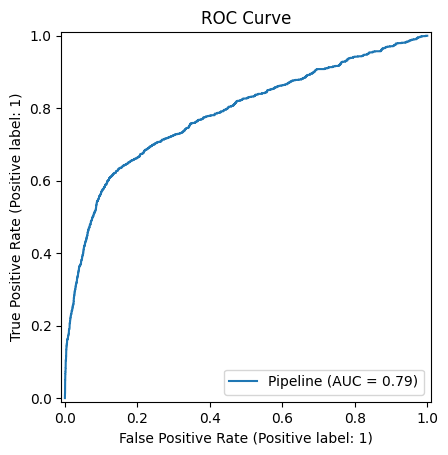

In [50]:


RocCurveDisplay.from_estimator(model_xgb, X_test, Y_test)
plt.title('ROC Curve')
plt.show()

Feature Importance
XGBoost modelinə görə hədəf dəyişənə ən çox təsir edən dəyişənlər

<BarContainer object of 43 artists>

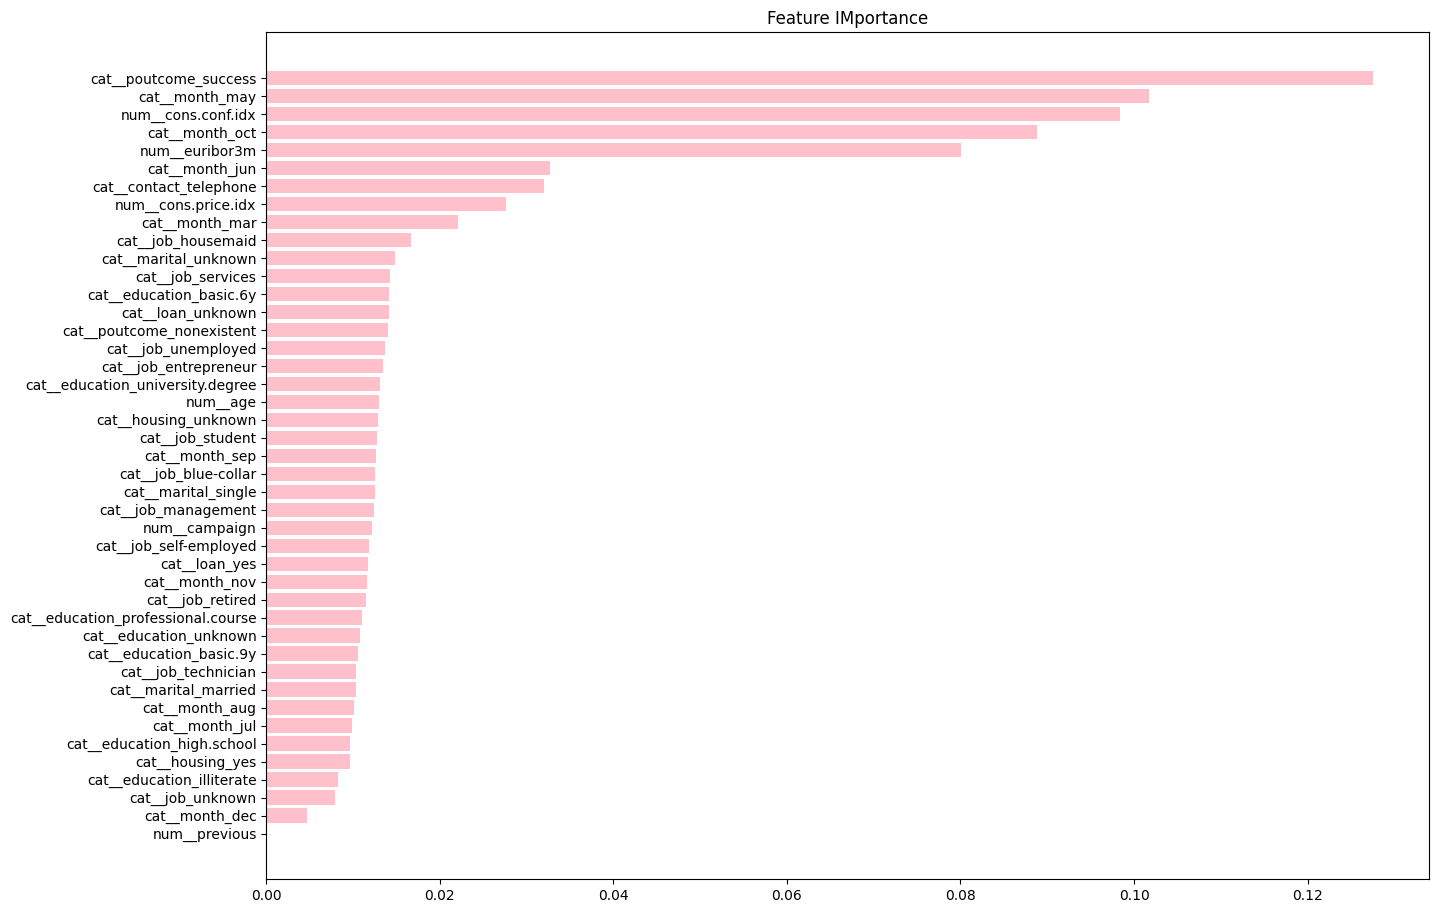

In [53]:
importances = model_xgb.named_steps['classifier'].feature_importances_
feature_names = model_xgb.named_steps['preprocessor'].get_feature_names_out()
importances_df = pd.DataFrame({'Features': feature_names,
                                'Importances': importances }).sort_values('Importances',ascending = True)
plt.figure(figsize = (15,11))
plt.title('Feature IMportance')
plt.barh(importances_df['Features'],importances_df['Importances'],color = 'pink')

Ən yaxşı model XGBoost oldu — F1: 0.48, ROC AUC: 0.79.
Dataset imbalanced olduğu üçün (yes: 11%) minority class üçün nəticələr bu səviyyədədir.